In [1]:
setwd("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb")
library(data.table)
library(pROC)
library(reshape2)
library(bigstatsr)
library(ggplot2)
library(ggrastr)

Type 'citation("pROC")' for a citation.


Attaching package: 'pROC'


The following objects are masked from 'package:stats':

    cov, smooth, var



Attaching package: 'reshape2'


The following objects are masked from 'package:data.table':

    dcast, melt




In [2]:
library(ggplot2)
library(dplyr)
library(ggsci)
library(ggrastr)
library(ggrepel)
library(data.table)
library(latex2exp)


Attaching package: 'dplyr'


The following objects are masked from 'package:data.table':

    between, first, last


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




In [3]:
dir = "/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/prs/validation"

In [4]:
args <- list(
    summary_ldsc = "data/prs/validation/ldsc_summary.txt.gz",
    summary_prs_cts = "data/prs/validation/pgs_cor_summary.txt.gz",
    summary_prs_bin = "data/prs/validation/pgs_auc_summary.txt.gz",
    bin_header = 'data/phenotypes/filtered_phenotypes_binary_header.tsv',
    cts_header = 'data/phenotypes/filtered_phenotypes_cts_manual.tsv'
)

In [27]:
ldsc <- fread(args$summary_ldsc)
cts <- fread(args$summary_prs_cts)
bin <- fread(args$summary_prs_bin)

In [28]:
binary_header <- readLines(args$bin_header)
binary_header <- binary_header[!grepl("primary_care", binary_header)]
cts_header <- paste0(readLines(args$cts_header),"_int")

In [29]:
colnames(ldsc) <- paste0("ldsc_",colnames(ldsc))

In [30]:
colnames(ldsc)[colnames(ldsc) == "ldsc_phenotype"] <- "phenotype"

In [31]:
res_bin <- merge(ldsc, bin, all.x = TRUE)
res_bin <- res_bin[res_bin$phenotype %in% binary_header,]
res_cts <- merge(ldsc, cts, all.x = TRUE)
res_cts <- res_cts[res_cts$phenotype %in% cts_header,]

In [32]:
res_bin$included <- res_bin$ldsc_pvalue < 1e-5
res_cts$included <- res_cts$ldsc_pvalue < 1e-5
#res_bin$included <- ifelse(!is.na(res_bin$auc_mean), "Yes", "No")
#res_cts$included <- ifelse(!is.na(res_cts$corr), "Yes", "No")

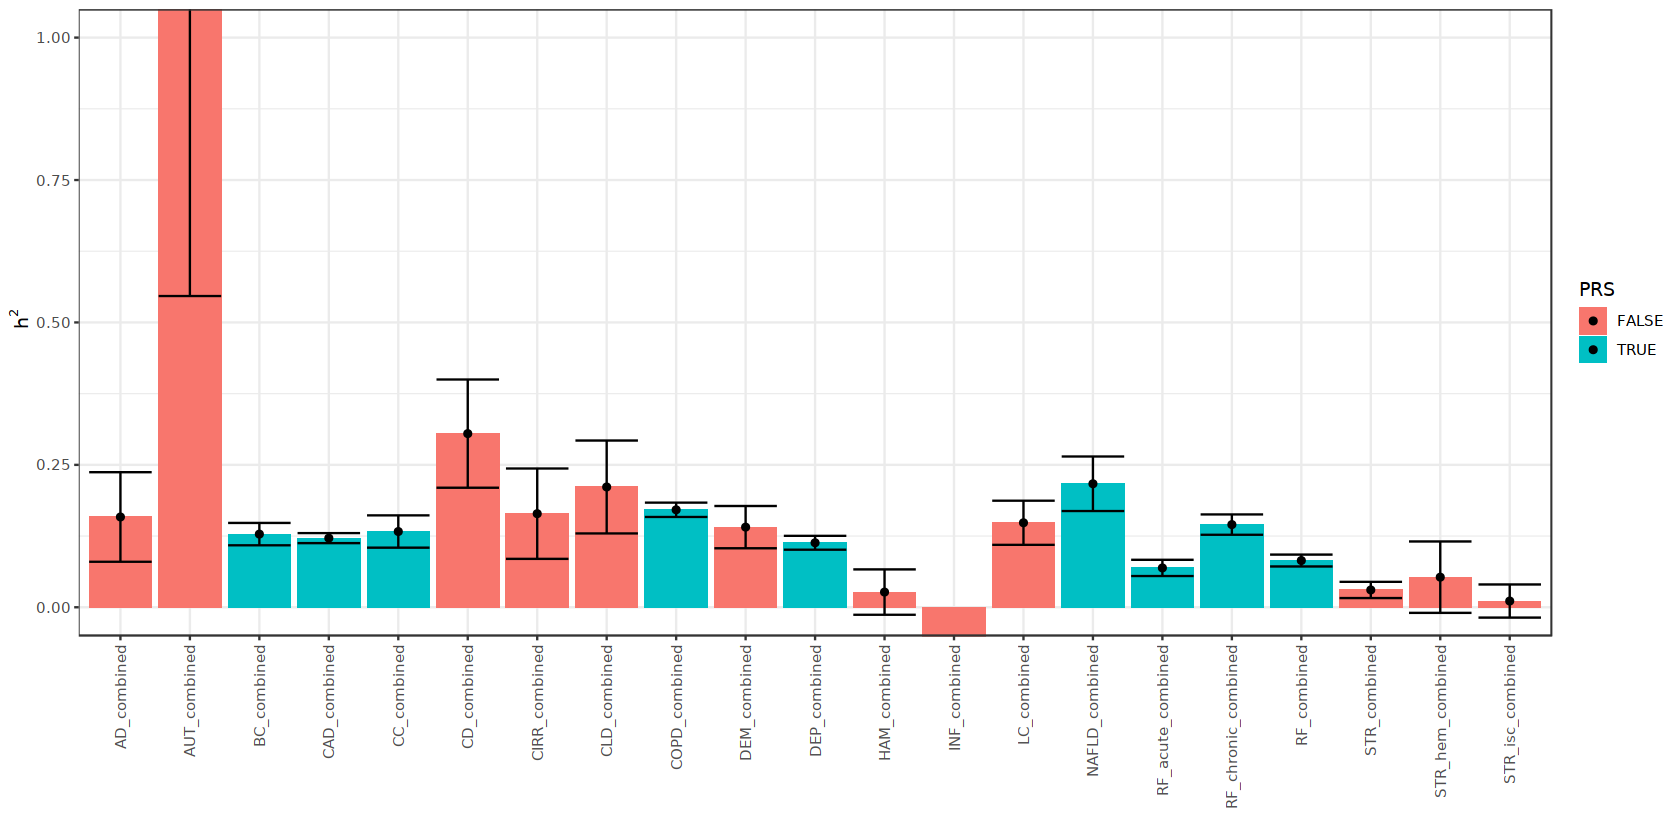

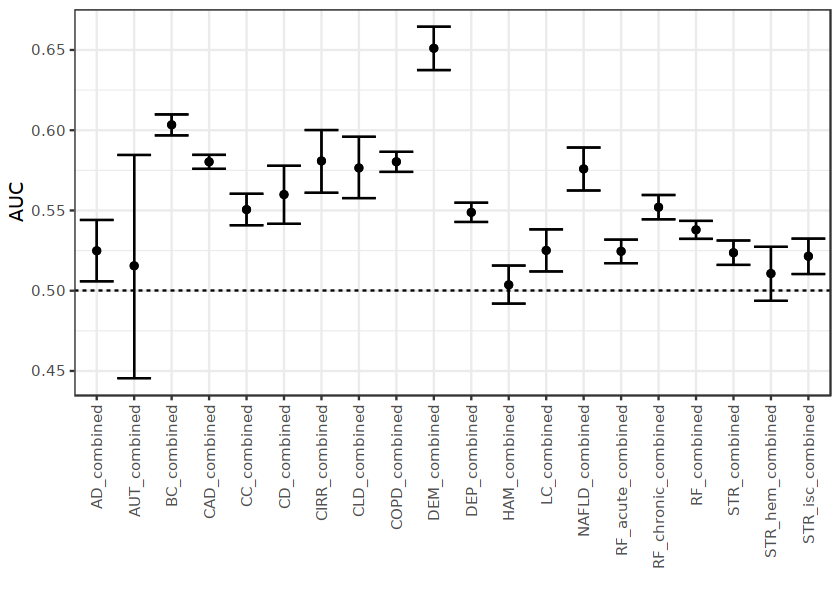

In [33]:
options(repr.plot.width=14, repr.plot.height=7)
p1 <- ggplot(res_bin[res_bin$ldsc_coef == "h2",], 
       aes(
           x=phenotype, #reorder(phenotype, ldsc_estimate),
           y=ldsc_estimate, 
           ymax=ldsc_estimate+ldsc_std_error,
           ymin=ldsc_estimate-ldsc_std_error,
           fill = included
           )
      ) + 
    geom_bar(stat="identity", position = 'dodge') +
    geom_point() +
    geom_errorbar() +
    ylab(bquote(~h^2)) + 
    xlab("") +
    labs(fill="PRS") +
    theme_bw() +
    coord_cartesian(ylim=c(0, 1)) +
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))
print(p1)

options(repr.plot.width=7, repr.plot.height=5)
p2 <- ggplot(res_bin[!is.na(res_bin$auc_mean),], 
       aes(
           x=phenotype, 
           y=auc_mean,
           ymax=auc_97_5_pct,
           ymin=auc_2_5_pct
           )
      ) + 
    geom_point() +
    geom_errorbar() +
    geom_hline(yintercept = 0.5, linetype = 'dashed') +
    xlab("") + 
    ylab("AUC") +
    theme_bw() +
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))


print(p2)

In [34]:
p1 <- ggplot(res_bin[res_bin$ldsc_coef == "h2",], 
       aes(
           y=phenotype, #reorder(phenotype, ldsc_estimate),
           x=ldsc_estimate, 
           xmax=ldsc_estimate+ldsc_std_error,
           xmin=ldsc_estimate-ldsc_std_error,
           fill = included
           )
      ) + 
    geom_bar(stat="identity", position = 'dodge') +
    geom_point() +
    geom_errorbar() +
    theme_bw() +
    coord_cartesian(xlim=c(0, 1)) +
    xlab(bquote(~h^2)) + 
    ylab("Phenotypes") +
    guides(fill="none")

p2 <- ggplot(res_bin[res_bin$ldsc_coef == "intercept",], 
       aes(
           y=phenotype, #y=reorder(phenotype, ldsc_estimate),
           x=ldsc_estimate, 
           xmax=ldsc_estimate+ldsc_std_error,
           xmin=ldsc_estimate-ldsc_std_error,
           )
      ) + 
    geom_point() +
    geom_errorbar() +
    xlab("Intercept") +
    geom_vline(xintercept = 1, linetype = 'dashed') +
    theme_bw() +
    theme(axis.title.y=element_blank(),
    axis.text.y=element_blank(),
    axis.ticks.y=element_blank())

p3 <- ggplot(res_bin[res_bin$ldsc_coef == "h2",], 
       aes(
           y=phenotype, #y=reorder(phenotype, ldsc_estimate),
           x=-log10(ldsc_pvalue)
           )
      ) + 
    geom_point() +
    xlab("P-value (h2)") +
    geom_vline(xintercept = -log10(1e-5), linetype = 'dashed') +
    theme_bw() +
    theme(axis.title.y=element_blank(),
    axis.text.y=element_blank(),
    axis.ticks.y=element_blank())

p4 <- ggplot(res_bin, 
       aes(
           y=phenotype, #y=reorder(phenotype, ldsc_estimate),
           x=auc_mean,
           xmax=auc_97_5_pct,
           xmin=auc_2_5_pct
           )
      ) + 
    geom_point() +
    geom_errorbar() +
    geom_vline(xintercept = 0.5, linetype = 'dashed') +
    xlab("AUC") + 
    ylab("Phenotypes") +
    theme_bw() +
    theme(axis.title.y=element_blank(),
        axis.text.y=element_blank(),
        axis.ticks.y=element_blank())

Warning message:
"Removed 2 rows containing missing values (geom_point)."


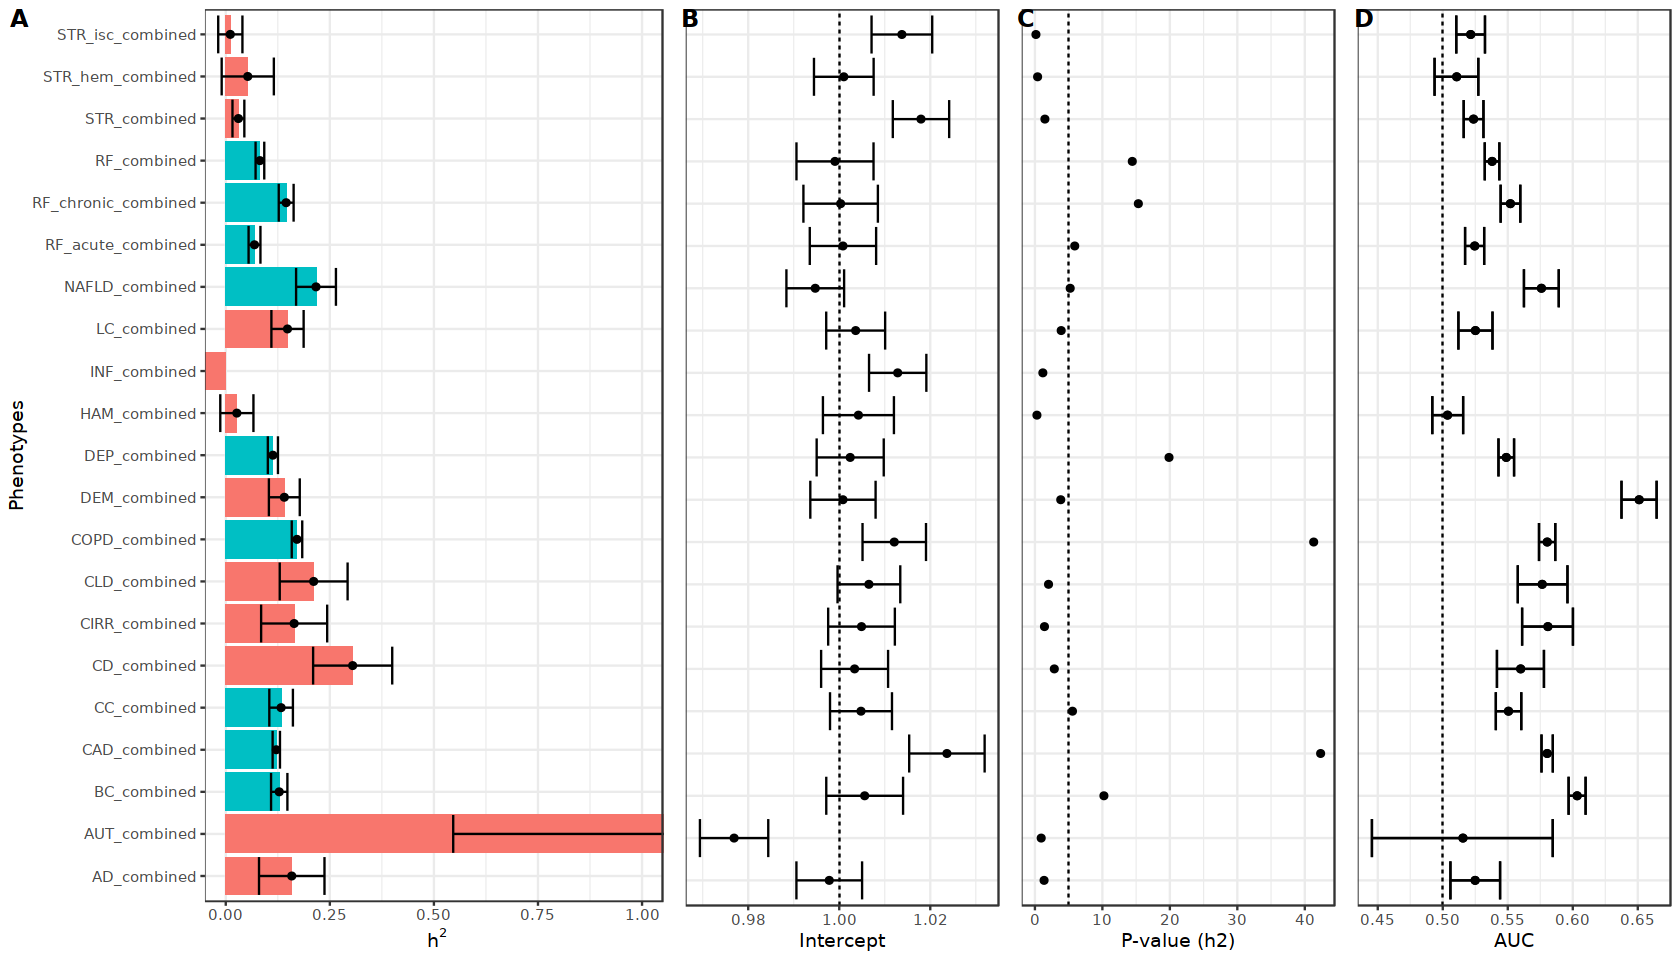

In [35]:
options(repr.plot.width=14, repr.plot.height=8)
cowplot::plot_grid(p1, p2, p3, p4, rel_widths = (c(0.4, 0.2, 0.2, 0.2)), ncol = 4, labels = "AUTO")

In [36]:
res_cts$label_ldsc <- paste0(round(res_cts$ldsc_estimate,2),"+",round(res_cts$ldsc_std_error, 2))
res_cts$label_corr <- paste0("[",round(res_cts$corr_ci_lower, 2),", ",
                                 round(res_cts$corr_ci_upper, 2), ']')

In [38]:
label_sig <- function(x, p){
    return(ifelse(x < 0.05, ifelse(x < p, "**","*"),""))
}

In [39]:
res_cts$ldsc_h2_sig_label <- label_sig(res_cts$pvalue, 1e-5)

In [40]:
p1 <- ggplot(res_cts[res_cts$ldsc_coef == "h2",], 
       aes(
           y=phenotype, #reorder(phenotype, ldsc_estimate),
           x=ldsc_estimate, 
           xmax=ldsc_estimate+ldsc_std_error,
           xmin=ldsc_estimate-ldsc_std_error,
           color=included
           )
      ) + 
    geom_pointrange() +
    xlab(expression(~h^2 ~ "(SE)")) + 
    ylab("Phenotypes") +
    theme_bw() +
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    scale_color_d3('category20c') +
    coord_cartesian(xlim=c(0, 0.6)) +
    guides(color="none")

p2 <- ggplot(res_cts[res_cts$ldsc_coef == "intercept",], 
       aes(
           y=phenotype,
           x=ldsc_estimate, 
           xmax=ldsc_estimate+ldsc_std_error,
           xmin=ldsc_estimate-ldsc_std_error,
           color=included
           )
      ) + 
    theme_bw() +
    geom_pointrange() +
    xlab(expression("intercept (SE)")) + 
    geom_vline(xintercept = 1, linetype = 'dashed') +
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    scale_color_d3('category20c') + 
    theme(axis.title.y=element_blank(),
    axis.text.y=element_blank(),
    axis.ticks.y=element_blank()) +
    guides(color="none")

p3 <- ggplot(res_cts[res_cts$ldsc_coef == "h2",], 
       aes(
           y=phenotype, #y=reorder(phenotype, ldsc_estimate),
           x=-log10(ldsc_pvalue),
           xmax=-log10(ldsc_pvalue),
           xmin=-log10(ldsc_pvalue),
           color=included
           )
      ) + 
    geom_pointrange() +
    xlab(expression(-log[10]*"(P-value)")) +
    geom_vline(xintercept = -log10(1e-5), linetype = 'dashed') +
    theme_bw() +
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    scale_color_d3('category20c') +
    theme(axis.title.y=element_blank(),
    axis.text.y=element_blank(),
    axis.ticks.y=element_blank()) +
    guides(color="none")

p4 <- ggplot(res_cts, 
       aes(
           y=phenotype, #y=reorder(phenotype, ldsc_estimate),
           x=corr,
           xmax=corr_ci_upper,
           xmin=corr_ci_lower,
           color=included
           )
      ) + 
    geom_point() +
    geom_pointrange_raste() +
    theme_bw() +
    scale_color_d3('category20c') +
    geom_vline(xintercept = 0, linetype = 'dashed') +
    xlab(expression("Pearson correlation (95% CI)")) + 
    ylab("Phenotypes") +
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    theme(axis.title.y=element_blank(),
        axis.text.y=element_blank(),
        axis.ticks.y=element_blank()) +
    guides(color="none")

ERROR: Error in geom_pointrange_raste(): could not find function "geom_pointrange_raste"


Warning message:
"Removed 2 rows containing missing values (geom_point)."


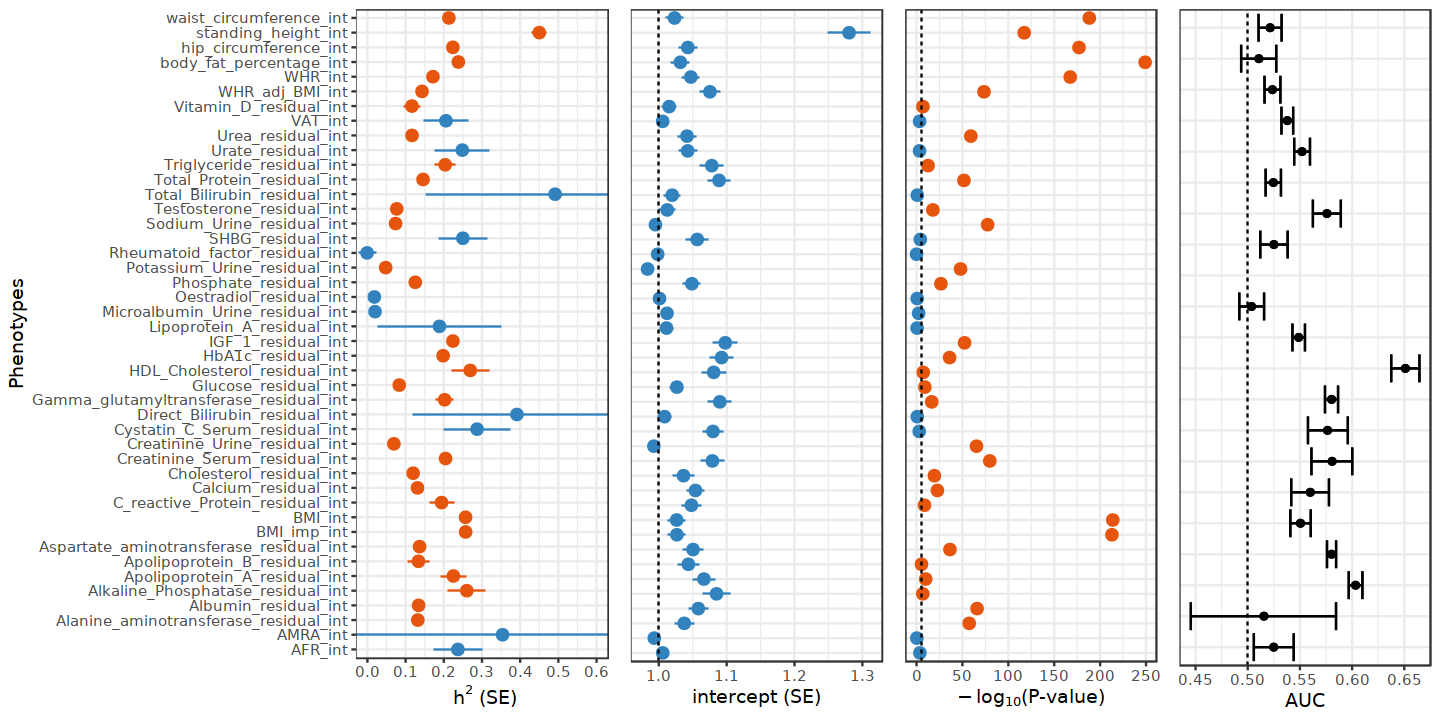

In [42]:
options(repr.plot.width=12, repr.plot.height=6)
plt <- cowplot::plot_grid(p1, p2, p3, p4, rel_widths = (c(0.45, 0.2, 0.2, 0.2)), ncol = 4, nrow = 1)
print(plt)

In [68]:
# setup color scale
my_colors <- c("grey",""#4DBBD5B2"")
names(my_colors) <- c(TRUE, FALSE)

fill_scale <- scale_fill_manual(name = "Phenotype", values = my_colors)
color_scale <- scale_color_manual(name = "Phenotype", values = my_colors)

ERROR: Error in parse(text = x, srcfile = src): <text>:3:1: unexpected symbol
2: my_colors <- c("grey",""#4DBBD5B2"")
3: names
   ^


In [62]:
p1 <- ggplot(res_bin[res_bin$ldsc_coef == "h2",], 
       aes(
           y=phenotype, #reorder(phenotype, ldsc_estimate),
           x=ldsc_estimate, 
           xmax=ldsc_estimate+ldsc_std_error,
           xmin=ldsc_estimate-ldsc_std_error,
           color=included
           )
      ) + 
    geom_pointrange() +
    xlab(expression(~h^2 ~ "(SE)")) + 
    ylab("Phenotypes") +
    theme_bw() +
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    scale_color_d3('category20c') +
    coord_cartesian(xlim=c(0, 1)) +
    theme(
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        legend.position="none"
    ) + guides(color="none")

p2 <- ggplot(res_bin[res_bin$ldsc_coef == "intercept",], 
       aes(
           y=phenotype,
           x=ldsc_estimate, 
           xmax=ldsc_estimate+ldsc_std_error,
           xmin=ldsc_estimate-ldsc_std_error,
           color=included
           )
      ) + 
    theme_bw() +
    geom_pointrange() +
    xlab(expression("intercept (SE)")) + 
    geom_vline(xintercept = 1, linetype = 'dashed') +
    scale_x_continuous(breaks=scales::pretty_breaks(n=3)) +
    scale_color_d3('category20c') + 
    theme(axis.title.y=element_blank(),
        axis.text.y=element_blank(),
        axis.ticks.y=element_blank(),
        strip.text = element_text(size=16),
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        legend.position="none"
    ) + guides(color="none")

p3 <- ggplot(res_bin[res_bin$ldsc_coef == "h2",], 
       aes(
           y=phenotype, #y=reorder(phenotype, ldsc_estimate),
           x=-log10(ldsc_pvalue),
           xmax=-log10(ldsc_pvalue),
           xmin=-log10(ldsc_pvalue),
           color=included
           )
      ) + 
    geom_pointrange() +
    xlab(expression(log[10]*"(P-value)")) +
    geom_vline(xintercept = -log10(1e-5), linetype = 'dashed') +
    theme_bw() +
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    scale_color_d3('category20c') +
    theme(axis.title.y=element_blank(),
        axis.text.y=element_blank(),
        axis.ticks.y=element_blank(),
        strip.text = element_text(size=16),
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        legend.position="none"
    ) + guides(color="none")

p4 <- ggplot(res_bin, 
       aes(
           y=phenotype, #y=reorder(phenotype, ldsc_estimate),
           x=auc_mean,
           xmax=auc_2_5_pct,
           xmin=auc_97_5_pct,
           color=included
           )
      ) + 
    geom_point() +
    geom_pointrange() +
    theme_bw() +
    scale_color_d3('category20c') +
    geom_vline(xintercept = 0.5, linetype = 'dashed') +
    xlab(expression("AUROC (95% CI)")) + 
    ylab("Phenotypes") +
    scale_x_continuous(breaks=scales::pretty_breaks(n=5)) +
    theme(axis.title.y=element_blank(),
        axis.text.y=element_blank(),
        axis.ticks.y=element_blank(),
        strip.text = element_text(size=16),
        axis.text=element_text(size=14),
        axis.title=element_text(size=14,face="bold"),
        plot.title = element_text(hjust=0.5),
        plot.subtitle = element_text(hjust=0.5),
        legend.position="none"
    ) + guides(color="none")

Warning message:
"Removed 2 rows containing missing values (geom_point)."
Warning message:
"Removed 2 rows containing missing values (geom_pointrange)."


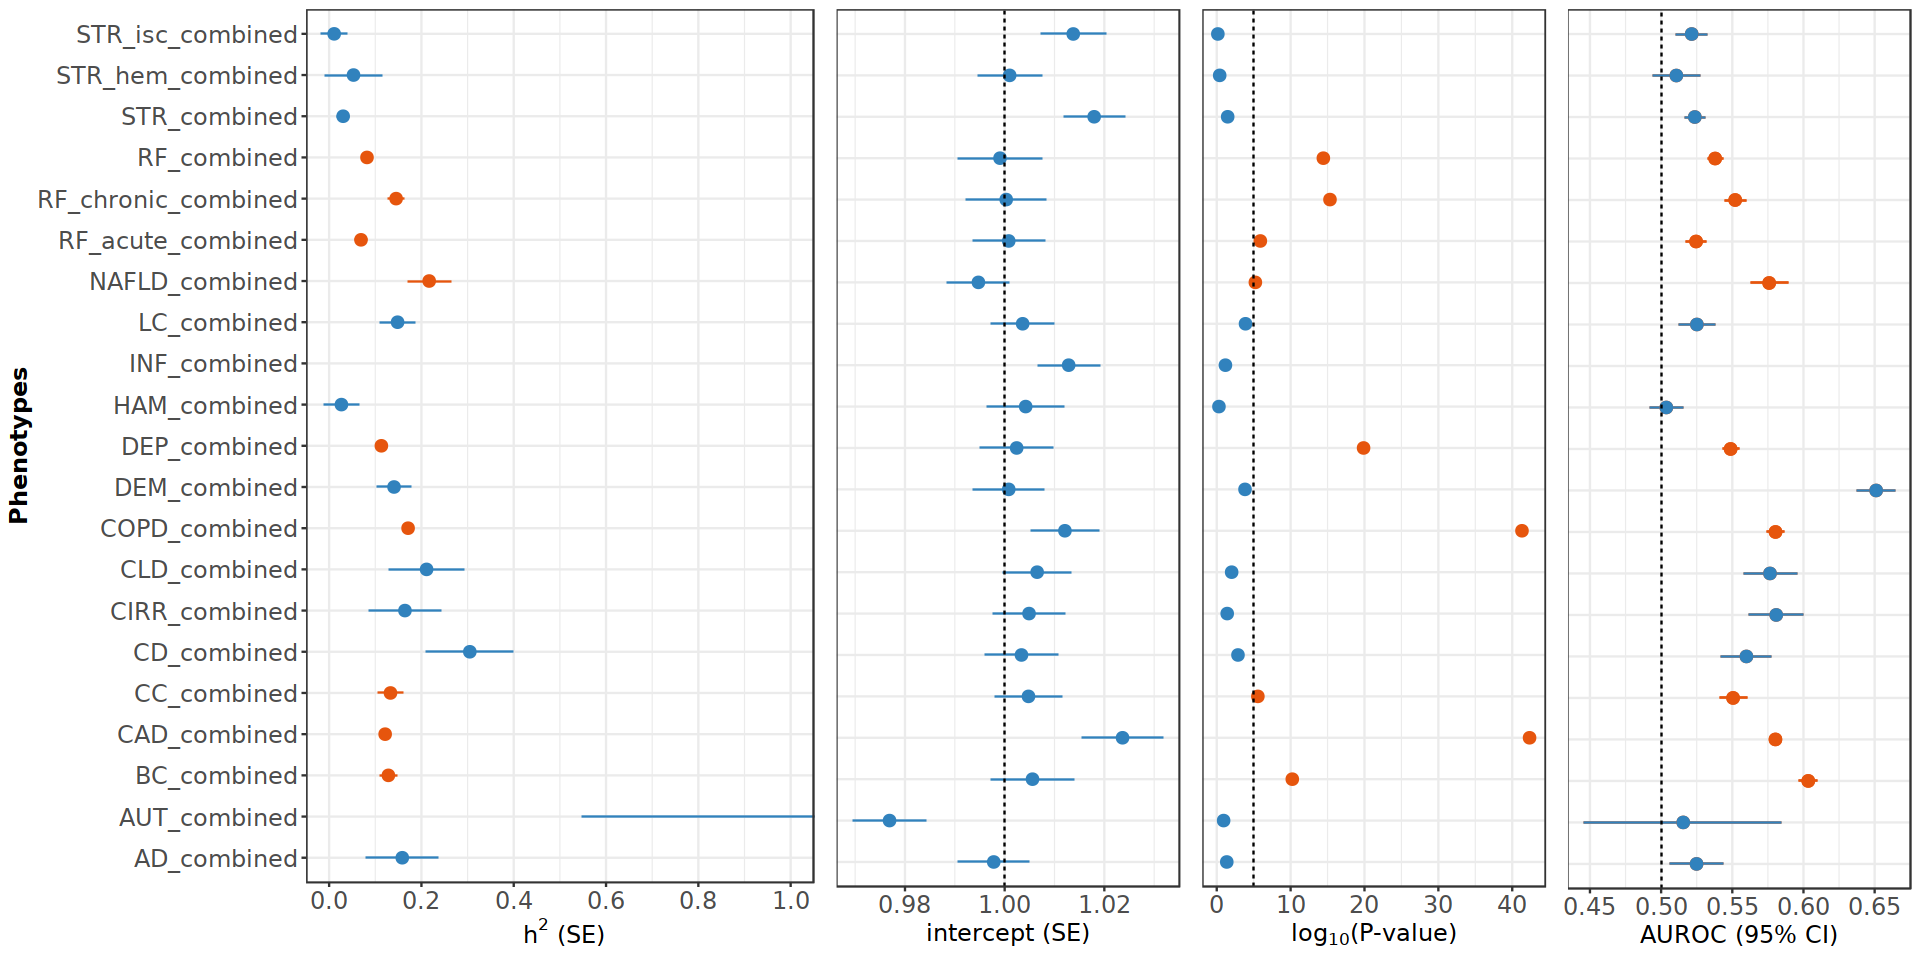

In [64]:
options(repr.plot.width=16, repr.plot.height=8)
cowplot::plot_grid(p1, p2, p3, p4, rel_widths = (c(0.45, 0.2, 0.2, 0.2)), ncol = 4, nrow = 1)

In [229]:
res_bin$trait <- "binary"
res_cts$trait <- "quantiative"
h2_combined <- rbind(
    res_bin[res_bin$ldsc_coef == "h2",c("ldsc_estimate","ldsc_std_err")],
    res_cts[res_cts$ldsc_coef == "h2",c()]
)

ERROR: Error in rbindlist(l, use.names, fill, idcol): Column 10 ['correlation'] of item 2 is missing in item 1. Use fill=TRUE to fill with NA (NULL for list columns), or use.names=FALSE to ignore column names.


In [263]:
carried_forward <- c(cts$phenotype, bin$phenotype )
ldsc$ok <- FALSE
ldsc$ok[ldsc$phenotype %in% carried_forward ] <- TRUE
ldsc$trait <- ifelse(ldsc$phenotype %in% cts$phenotype, "quantitative","binary")

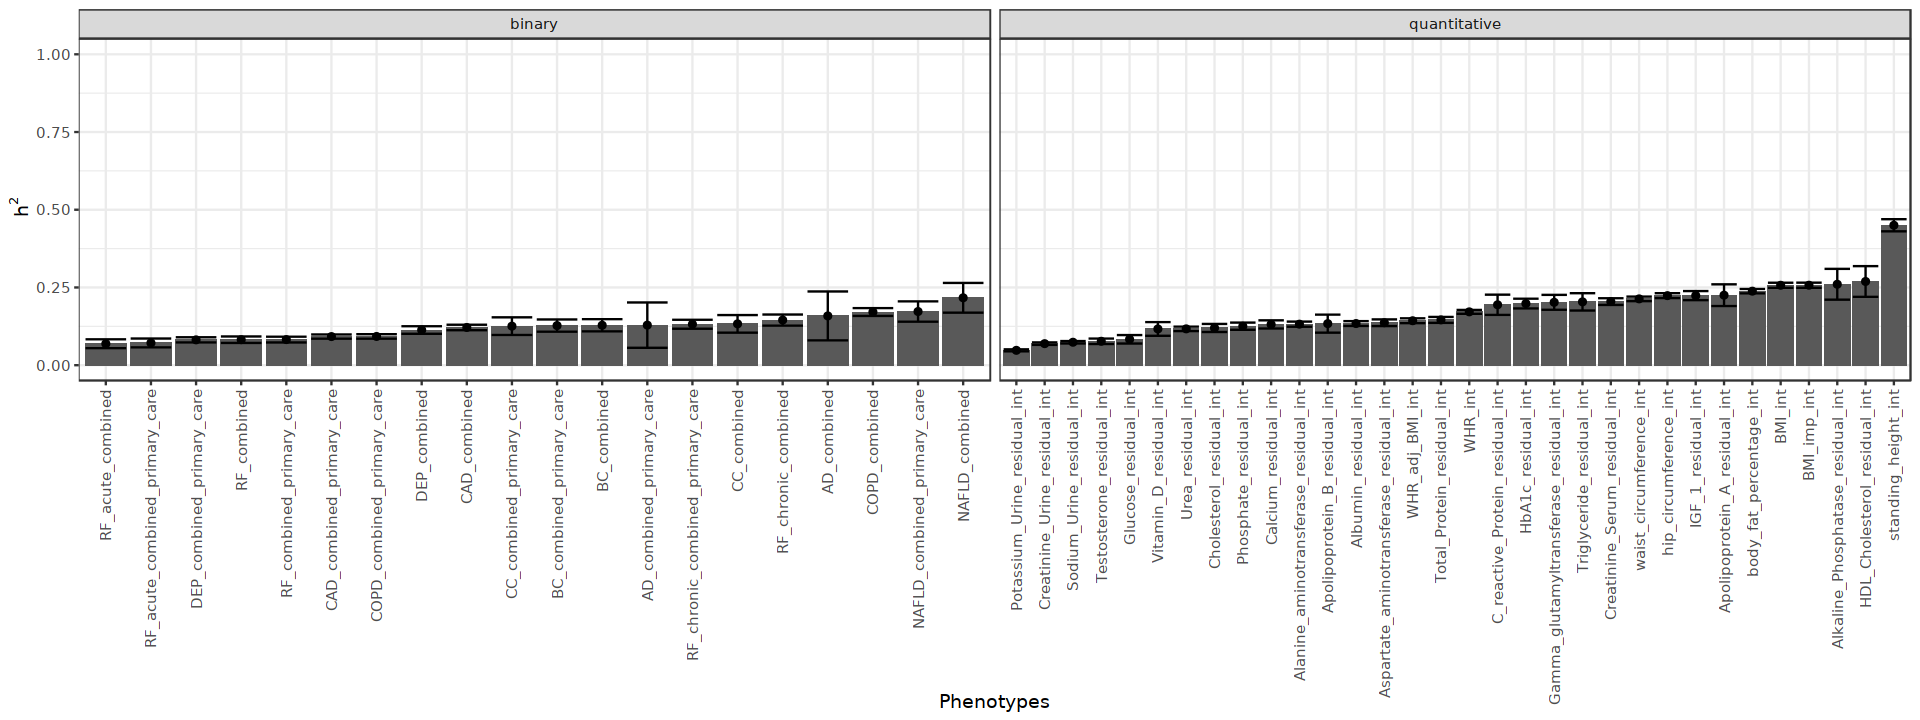

In [270]:
options(repr.plot.width=16, repr.plot.height=6)
p1 <- ggplot(ldsc[ldsc$ldsc_coef == "h2" & ldsc$ok,], 
       aes(
           x=reorder(phenotype, ldsc_estimate),
           y=ldsc_estimate, 
           ymax=ldsc_estimate+ldsc_std_error,
           ymin=ldsc_estimate-ldsc_std_error
           )
      ) + 
    geom_bar(stat="identity", position = 'dodge') +
    geom_point() +
    geom_errorbar() +
    ylim(c(0,1)) + 
    ylab(bquote(~h^2)) + 
    xlab("Phenotypes") +
    labs(fill="P-value < 1e-5") +
    theme_bw() +
    facet_wrap(~trait, scales = "free_x") +
    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust=1))

p1

In [265]:
sum(ldsc$ldsc_coef == "h2" & ldsc$ok)

[1] 52

In [ ]:

library(argparse)
library(data.table)
library(bigstatsr)

main <- function(args){

    print(args)
    stopifnot(file.exists(args$phenotype_cts))
    stopifnot(dir.exists(args$directory))
    stopifnot(dir.exists(dirname(args$out_prefix)))

    # Load polygenic risk scores
    files <- list.files(args$directory, pattern = ".txt.gz", full.names = TRUE)
    files <- files[!grepl("chrom",files)]

    # comctse files
    lst <- lapply(files, fread)
    mrg <- Reduce(merge, lst)
    mrg$eid <- mrg$sid

    # read ctsary phenotypes
    d_cts <- fread(args$phenotype_cts)
    d_cts <- d_cts[d_cts$eid %in% mrg$eid,]
    cols_cts <- colnames(d_cts)

    # subset cols to ctsary
    cols <- gsub("_pgs","",colnames(mrg))
    cols <- cols[cols %in% cols_cts]
    d_cts <- d_cts[,colnames(d_cts) %in% cols, with = FALSE]
    dt <- merge(mrg, d_cts, by = 'eid')

    # calculate AUC
    cols <- cols[!cols %in% "eid"]
    lst <- lapply(cols, function(col){
        print(col)
        col_pgs <- paste0(col,'_pgs')
        cur_dt <- dt[,colnames(dt) %in% c('eid',col,col_pgs), with = FALSE]
        cur_dt <- cur_dt[!is.na(cur_dt[[col]]) & !is.na(cur_dt[[col_pgs]]),]
        f <- as.formula(paste0(col, "~", col_pgs))
        fit <- summary(lm(f, data = cur_dt))
        
        
        
        correlation <- cor(cur_dt[[col]], cur_dt[[col_pgs]])

        # perform Z-test
        estimate <- fit$coefficients[2,1]
        stderr <- fit$coefficients[2,2]
        zscore <- estimate / stderr
        pvalue <- 2 * pnorm(abs(zscore), lower.tail = FALSE, log.p = FALSE)
        log_pvalue <- 2 * pnorm(abs(zscore), lower.tail = FALSE, log.p = TRUE)
        d_out <- data.frame(
            phenotype = col,
            correlation = correlation,
            estimate = estimate,
            std_error = stderr,
            zstat = zscore,
            pvalue = pvalue,
            log_pvalue = log_pvalue,
            pred_n = nrow(cur_dt)
        )
        return(d_out)
    })

    # write final file
    final <- data.table(do.call(rbind, lst))
    outfile <- paste0(args$out_prefix, ".txt.gz")
    write(paste("writing",outfile),stdout())
    fwrite(final, outfile, sep = "\t")

}

In [235]:
aucBOOT

ERROR: Error in eval(expr, envir, enclos): object 'aucBOOT' not found


In [236]:
AUCBoot

function (pred, target, nboot = 10000, seed = NA, digits = NULL) 
{
    assert_lengths(pred, target)
    assert_noNA(pred)
    assert_01(target)
    y <- as.logical(target)
    ord <- order(pred, y)
    pred <- pred[ord]
    y <- y[ord]
    if (!is.na(seed)) {
        old <- .Random.seed
        on.exit({
            .Random.seed <<- old
        })
        set.seed(seed)
    }
    repl <- boot_auc_sorted_tab(pred, y, nboot)
    if (nbNA <- sum(is.na(repl))) 
        warning2("%d/%d bootstrap replicates were mono-class.", 
            nbNA, nboot)
    res <- c(Mean = mean(repl, na.rm = TRUE), stats::quantile(repl, 
        c(0.025, 0.975), na.rm = TRUE), Sd = stats::sd(repl, 
        na.rm = TRUE))
    round2(res, digits)
}
<bytecode: 0x55cd2841c7d0>
<environment: namespace:bigstatsr>

function (x, y, n_boot) 
{
    .Call(`_bigstatsr_boot_auc_sorted_tab`, x, y, n_boot)
}
<bytecode: 0x55cd25a65f28>
<environment: namespace:bigstatsr>

In [273]:
d <- rnorm(1000)

In [275]:
length(unique(sample(d, replace = TRUE)))

[1] 651

In [276]:
?sample

Warning message in seq_len(head.end.idx):
"first element used of 'length.out' argument"
ERROR while rich displaying an object: Error in seq_len(head.end.idx): argument must be coercible to non-negative integer

Traceback:
1. FUN(X[[i]], ...)
2. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
3. tryCatchList(expr, classes, parentenv, handlers)
4. tryCatchOne(expr, names, parentenv, handlers[[1L]])
5. doTryCatch(return(expr), name, parentenv, handler)
6. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_conte